In [ ]:
import os
import urllib.parse
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the hidden variables from the .env file
load_dotenv()


# 2. Build your connection engine
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)



In [2]:
from sqlalchemy import text

# 1. Test using a clean SQLAlchemy connection block
try:
    with engine.connect() as connection:
        # Run a lightweight raw SQL query to test responsiveness
        result = connection.execute(text("SELECT NOW();"))
        db_time = result.scalar()
        
    print("🚀 CONNECTION SUCCESSFUL!")
    print(f"PostgreSQL server time: {db_time}")

except Exception as e:
    print("❌ CONNECTION FAILED!")
    print(f"Error details: {e}")


🚀 CONNECTION SUCCESSFUL!
PostgreSQL server time: 2026-08-29 22:08:35.660047+08:00


In [3]:
# 1. Write the SQL query to pull 5 items from the movies table
query = """
SELECT 
    -- Core Identifiers & Metadata
    m.movie_id,
    m.imdb_id,
    m.title,
    m.original_title,
    m.status,
    m.original_language,
    m.adult,
    m.video,
    
    -- Temporal Features
    m.release_date,
    EXTRACT(YEAR FROM m.release_date) AS release_year,
    EXTRACT(MONTH FROM m.release_date) AS release_month,
    EXTRACT(DOW FROM m.release_date) AS release_day_of_week,
    
    -- Continuous Quantitative Metrics (Financials, Audience Scores, Runtime)
    m.budget,
    m.revenue,
    (m.revenue - m.budget) AS net_profit,
    CASE 
        WHEN m.budget > 0 THEN (m.revenue / CAST(m.budget AS DECIMAL))
        ELSE NULL 
    END AS roi,
    m.runtime,
    m.popularity AS movie_popularity,
    m.vote_average,
    m.vote_count,
    
    -- Franchise / Collection Metadata
    c.name AS collection_name,
    CASE WHEN m.belongs_to_collection_id IS NOT NULL THEN 1 ELSE 0 END AS is_part_of_franchise,
    
    -- Primary Category Aggregations
    pg.primary_genre,
    pc.primary_production_company,
    pco.primary_country,
    
    -- Primary Director & Key Cast Metadata
    dir.director_name,
    cast_agg.lead_cast,
    
    -- Timestamps
    m.created_at,
    m.updated_at

FROM movies m

-- Join Collection info
LEFT JOIN collections c 
    ON m.belongs_to_collection_id = c.collection_id

-- Subquery: Extract Primary Genre per movie
LEFT JOIN (
    SELECT 
        mg.movie_id,
        g.name AS primary_genre
    FROM (
        SELECT 
            movie_id, 
            genre_id,
            ROW_NUMBER() OVER (PARTITION BY movie_id ORDER BY genre_id) AS rn
        FROM movie_genres
    ) mg
    JOIN genres g ON mg.genre_id = g.genre_id
    WHERE mg.rn = 1
) pg ON m.movie_id = pg.movie_id

-- Subquery: Extract Primary Production Company per movie
LEFT JOIN (
    SELECT 
        mc.movie_id,
        comp.name AS primary_production_company
    FROM (
        SELECT 
            movie_id, 
            company_id,
            ROW_NUMBER() OVER (PARTITION BY movie_id ORDER BY company_id) AS rn
        FROM movie_companies
    ) mc
    JOIN production_companies comp ON mc.company_id = comp.company_id
    WHERE mc.rn = 1
) pc ON m.movie_id = pc.movie_id

-- Subquery: Extract Primary Production Country per movie
LEFT JOIN (
    SELECT 
        prc.movie_id,
        cou.english_name AS primary_country
    FROM (
        SELECT 
            movie_id, 
            iso_3166_1,
            ROW_NUMBER() OVER (PARTITION BY movie_id ORDER BY iso_3166_1) AS rn
        FROM production_countries
    ) prc
    JOIN countries cou ON prc.iso_3166_1 = cou.iso_3166_1
    WHERE prc.rn = 1
) pco ON m.movie_id = pco.movie_id

-- Subquery: Extract Director
LEFT JOIN (
    SELECT 
        mc.movie_id,
        p.name AS director_name
    FROM movie_crew mc
    JOIN people p ON mc.person_id = p.person_id
    WHERE mc.job = 'Director'
) dir ON m.movie_id = dir.movie_id

-- Subquery: Aggregate Top 3 Lead Actors into a single string (PostgreSQL syntax)
LEFT JOIN (
    SELECT 
        cast_rank.movie_id,
        STRING_AGG(p.name, ', ') AS lead_cast
    FROM (
        SELECT 
            movie_id, 
            person_id, 
            cast_order,
            ROW_NUMBER() OVER (PARTITION BY movie_id ORDER BY cast_order ASC) AS rn
        FROM movie_cast
    ) cast_rank
    JOIN people p ON cast_rank.person_id = p.person_id
    WHERE cast_rank.rn <= 3
    GROUP BY cast_rank.movie_id
) cast_agg ON m.movie_id = cast_agg.movie_id;
"""
    # 2. Use Pandas to run the query and create a DataFrame
df = pd.read_sql(query, con=engine)
    
    # 3. Print success confirmation and dimensions
print(f"Pandas loaded {df.shape[0]} rows and {df.shape[1]} columns successfully!")
    
    # 4. Display the data grid cleanly
display(df)


Pandas loaded 16319 rows and 29 columns successfully!


,movie_id,imdb_id,title,original_title,status,original_language,adult,video,release_date,release_year,...,vote_count,collection_name,is_part_of_franchise,primary_genre,primary_production_company,primary_country,director_name,lead_cast,created_at,updated_at
0,1084242,tt26443597,Zootopia 2,Zootopia 2,Released,en,False,False,2025-11-26,2025.0,...,3322,Zootopia Collection,1,Adventure,Walt Disney Animation Studios,Canada,Jared Bush,"Ginnifer Goodwin, Ke Huy Quan, Jason Bateman",2026-08-24 19:14:25.174994,2026-08-24 22:46:15.267315
1,1288445,tt32338669,Mutiny,Mutiny,Released,en,False,False,2026-08-19,2026.0,...,137,NaN,0,Action,MadRiver Pictures,United Kingdom,Jean-François Richet,"Jason Statham, Annabelle Wallis, Roland Møller",2026-08-24 18:39:10.263845,2026-08-25 03:28:01.199819
2,1146972,tt14759062,Mobile Suit Gundam SEED FREEDOM,機動戦士ガンダムSEED FREEDOM,Released,ja,False,False,2024-01-26,2024.0,...,83,Mobile Suit Gundam SEED Freedom Collection,1,Animation,SUNRISE,Japan,Mitsuo Fukuda,"Soichiro Hoshi, Rie Tanaka, Akira Ishida",2026-08-24 20:03:12.336869,2026-08-24 20:03:15.053914
3,99,tt0185125,All About My Mother,Todo sobre mi madre,Released,es,False,False,1999-04-16,1999.0,...,2095,NaN,0,Drama,El Deseo,Spain,Pedro Almodóvar,"Cecilia Roth, Candela Peña, Marisa Paredes",2026-08-24 20:03:54.096184,2026-08-24 20:03:56.512480
4,163940,tt1636454,The Peddler,El ambulante,Released,es,False,False,2010-04-10,2010.0,...,5,NaN,0,Documentary,NaN,Argentina,Lucas Marcheggiano,Daniel Burmeister,2026-08-24 20:04:00.808268,2026-08-24 20:04:01.775434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16314,381632,tt6447722,GG Bond Movie:Ultimate Battle,猪猪侠之终极决战,Released,zh,False,False,2015-07-10,2015.0,...,2,猪猪侠（系列）,1,Animation,NaN,China,NaN,"陆双, Qing Zu, 陈志荣",2026-08-25 08:49:00.094974,2026-08-25 08:49:00.838388
16315,1494978,tt21913198,Super Vixens 4,Super Vixens 4,Released,en,False,False,2022-01-18,2022.0,...,0,Super Vixens Collection,1,Action,NaN,NaN,NaN,NaN,2026-08-25 08:31:16.999440,2026-08-25 08:31:17.682868
16316,120454,,Spice Girls: The Return of the Spice Girls Tour,Spice Girls: The Return of the Spice Girls Tour,Released,en,False,False,2007-12-02,2007.0,...,6,NaN,0,Music,19 Entertainment,United Kingdom,NaN,"Geri Halliwell-Horner, Victoria Beckham, Emma ...",2026-08-25 09:10:10.193238,2026-08-25 09:10:11.115652
16317,1300939,NaN,Verguizas Cabronas,Verguizas Cabronas,Released,es,False,False,2024-06-08,2024.0,...,0,NaN,0,Action,TAI: Escuela Superior de Artes y Espectaculos,NaN,NaN,"Sebastián espósito, Juan Carlos da silva, Aima...",2026-08-25 09:26:34.661767,2026-08-25 09:26:35.687918


In [ ]:
# query = """
# """
#     # 2. Use Pandas to run the query and create a DataFrame
# df = pd.read_sql(query, con=engine)
    
#     # 3. Print success confirmation and dimensions
# print(f"Pandas loaded {df.shape[0]} rows and {df.shape[1]} columns successfully!")
    
#     # 4. Display the data grid cleanly
# display(df)

In [ ]:
df.info

In [4]:
df.columns

Index(['movie_id', 'imdb_id', 'title', 'original_title', 'status',
       'original_language', 'adult', 'video', 'release_date', 'release_year',
       'release_month', 'release_day_of_week', 'budget', 'revenue',
       'net_profit', 'roi', 'runtime', 'movie_popularity', 'vote_average',
       'vote_count', 'collection_name', 'is_part_of_franchise',
       'primary_genre', 'primary_production_company', 'primary_country',
       'director_name', 'lead_cast', 'created_at', 'updated_at'],
      dtype='str')

In [5]:
df_display = df[['original_title', 'budget', 'revenue', 'release_date', 'poster_path']].copy()

df_display.head(2)

KeyError: "['poster_path'] not in index"

In [ ]:
from IPython.display import HTML

base_url = "https://image.tmdb.org/t/p/w500"

display(HTML(
    df_display.assign(
        poster_path=lambda x: x['poster_path'].apply(
            lambda p: f'<img src="{base_url}{p}" width="70">' if pd.notna(p) else ''
        )
    ).to_html(escape=False, index=False)
))

In [ ]:
base_url = "https://image.tmdb.org/t/p/w500"

# 1. Create your subset dataframe
subset = df_display[['original_title', 'budget', 'revenue', 'release_date', 'poster_path']].copy()

# 2. Transform the poster path column into HTML images
subset['poster_path'] = subset['poster_path'].apply(
    lambda p: f'<img src="{base_url}{p}" width="70">' if pd.notna(p) else ''
)

# 3. Display it using HTML
display(HTML(subset.to_html(escape=False, index=False)))

In [ ]:

# 1. Sort by revenue from highest to lowest and take the top 5
subset = df.sort_values(by='revenue', ascending=False)[['original_title', 'budget', 'revenue', 'release_date', 'poster_path']].head(5).copy()

# 2. Transform the poster path into HTML images
subset['poster_path'] = subset['poster_path'].apply(
    lambda p: f'<img src="{base_url}{p}" width="70">' if pd.notna(p) else ''
)

# 3. Display it using HTML
display(HTML(subset.to_html(escape=False, index=False)))

--- DESCRIPTIVE STATISTICS ---


,mean,median,std_dev,min,max,iqr
budget,1.815161e+07,3000000.00,3.627538e+07,0.000,6.588000e+08,2.000000e+07
revenue,5.575409e+07,10082005.00,1.475565e+08,0.000,2.923706e+09,4.170208e+07
runtime,9.957136e+01,102.00,3.695554e+01,0.000,9.600000e+02,2.700000e+01
movie_popularity,7.188870e+00,5.09,1.787835e+01,0.055,1.657233e+03,4.036500e+00
vote_average,6.036313e+00,6.50,1.936001e+00,0.000,1.000000e+01,1.300000e+00
vote_count,1.441401e+03,381.00,3.022803e+03,0.000,4.088500e+04,1.338500e+03


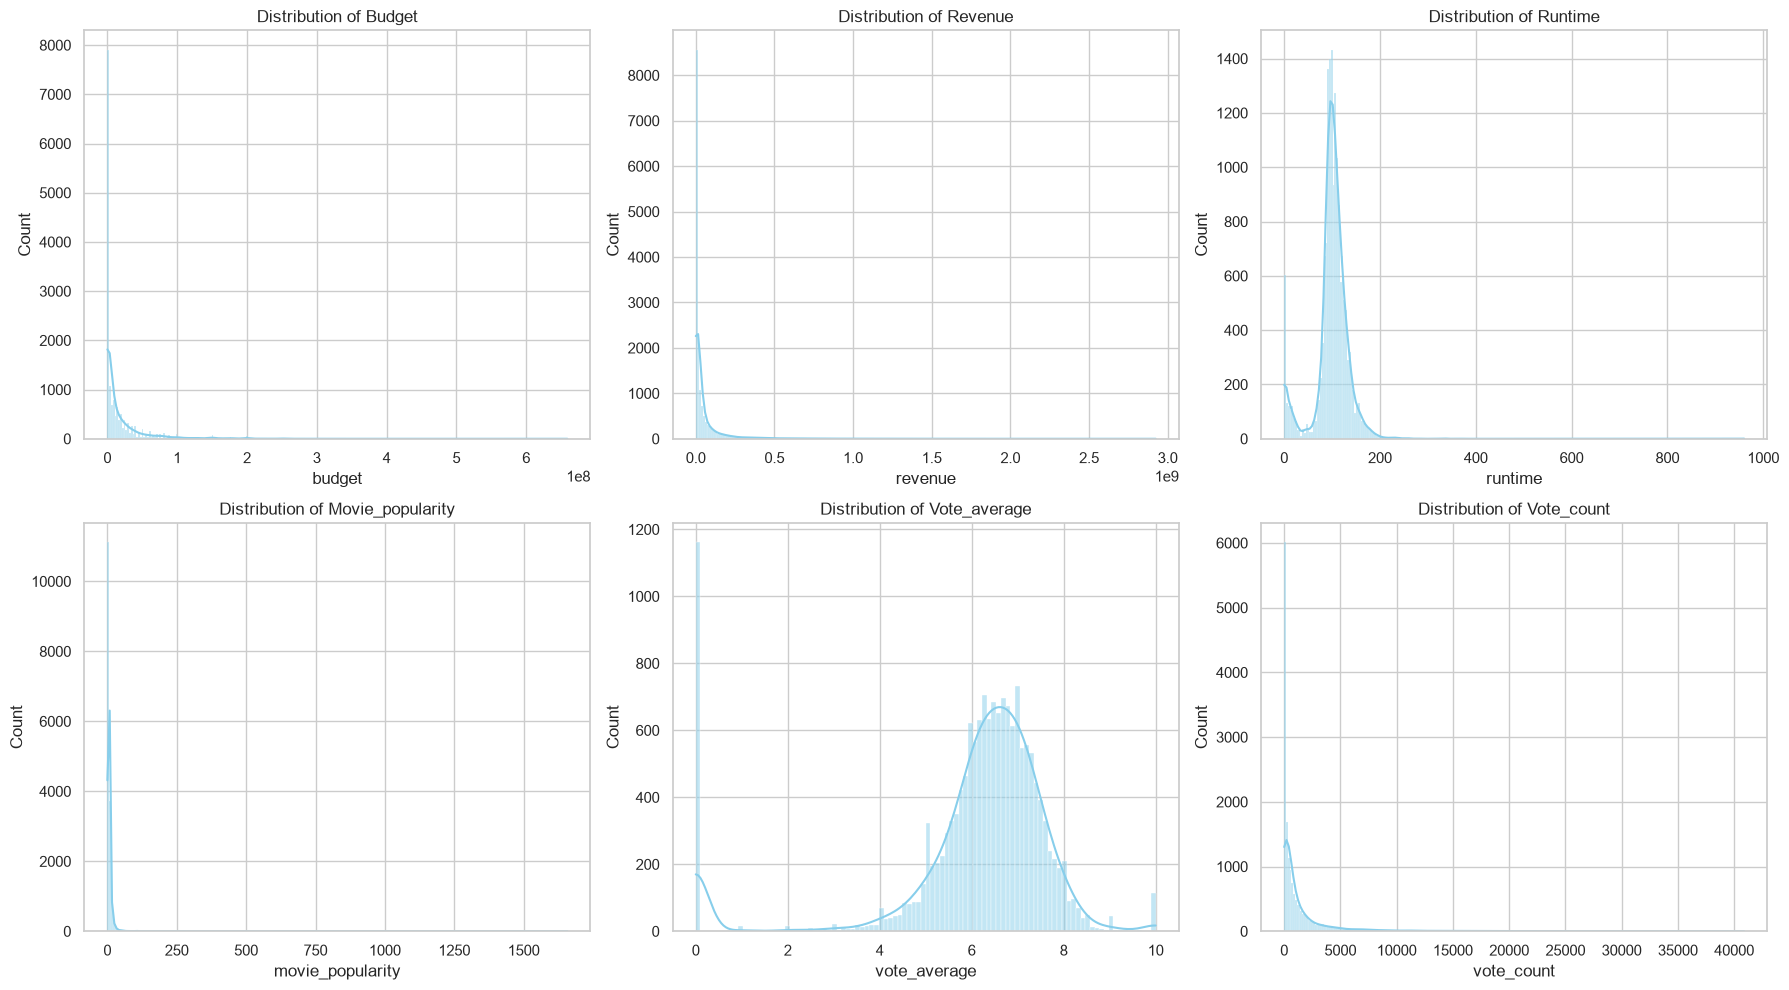

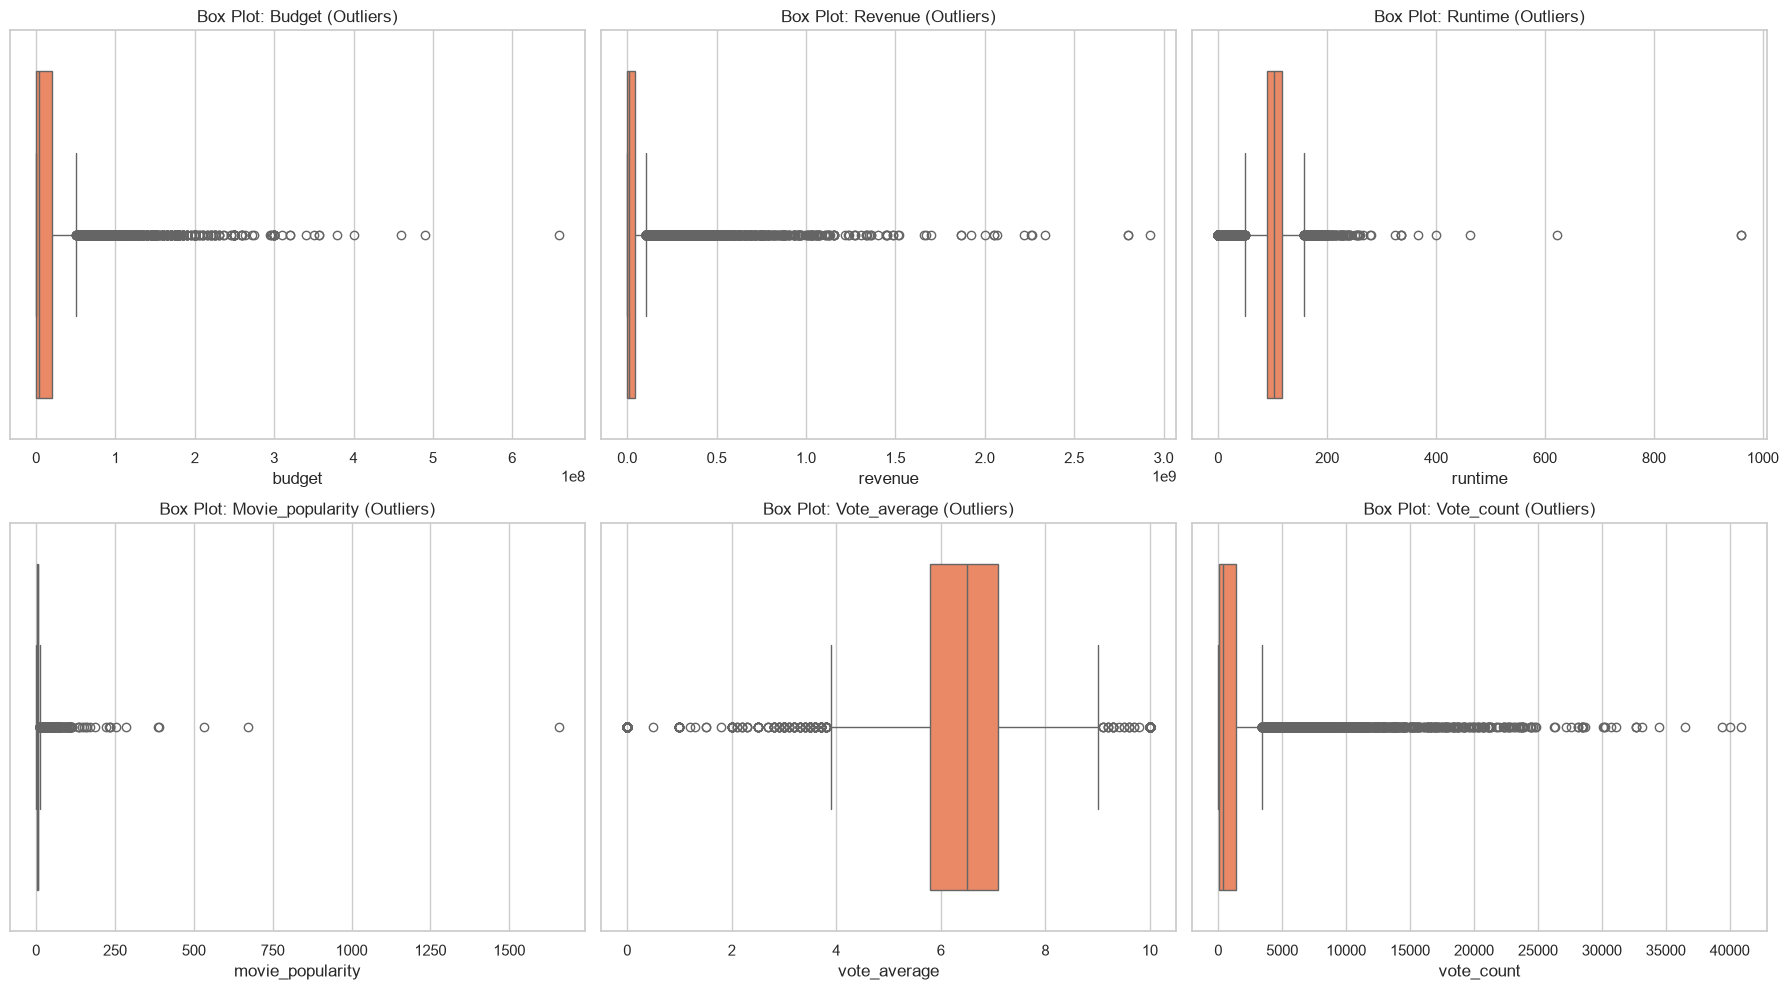

In [23]:

# Configure visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

df["release_date"] = pd.to_datetime(df["release_date"])

numeric_cols = [
    "budget",
    "revenue",
    "runtime",
    "movie_popularity",
    "vote_average",
    "vote_count",
]

# 1. Summary Metrics Table
summary_stats = df[numeric_cols].describe().T
summary_stats["std_dev"] = df[numeric_cols].std()
summary_stats["iqr"] = df[numeric_cols].quantile(0.75) - df[
    numeric_cols
].quantile(0.25)
summary_stats = summary_stats[
    ["mean", "50%", "std_dev", "min", "max", "iqr"]
].rename(columns={"50%": "median"})

print("--- DESCRIPTIVE STATISTICS ---")
display(summary_stats)

# 2. Distributions (Histograms + KDE)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribution of {col.capitalize()}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# 3. Outlier Detection (Box Plots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color="coral")
    axes[i].set_title(f"Box Plot: {col.capitalize()} (Outliers)")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()


In [39]:
# 1. Define the columns you want to see
zero_revenue_col = [
    "title",
    "budget",
    "revenue",
    "runtime",
    "movie_popularity",
    "vote_average",
    "vote_count",
]
# View the 5 films with the lowest non-zero revenue
lowest_films_list = df[df['revenue'] > 100][zero_revenue_col].sort_values(by='revenue', ascending=True)[zero_revenue_col].head(5)

print(lowest_films_list)



                          title  budget  revenue  runtime  movie_popularity  \
7513                    Mudborn       0      111      111             5.693   
7565                 Alas Roban       0      111      111             7.056   
2220              Dano Lunático    1500      200        8             5.289   
2843            The Emoji Movie   50000      216       86            10.971   
10742  Home Sweet Home: Rebirth       0      235       93             4.955   

       vote_average  vote_count  
7513            7.2          58  
7565            4.4           8  
2220            0.0           0  
2843            5.4        3375  
10742           6.0         165  
